In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Read dataset
df_new = pd.read_csv(r"E:\Project_Analysis\Nutri_Class_project\Data\cleaned_encoded_food_dataset.csv")
df_new

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,...,Is_Gluten_Free_label,Food_Name_label,Meal_Type_breakfast,Meal_Type_dinner,Meal_Type_lunch,Meal_Type_snack,Preparation_Method_baked,Preparation_Method_fried,Preparation_Method_grilled,Preparation_Method_raw
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,...,0,6,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,...,1,4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,...,0,2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,...,1,9,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,...,0,3,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31320,103.937793,1.251053,0.452045,27.891970,14.836599,1.835365,2.326263,0.000000,53.690101,72.507408,...,1,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
31321,246.063812,10.269973,13.106895,36.416636,5.684908,1.571570,600.167326,20.839330,81.153823,41.760973,...,0,6,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
31322,299.997105,12.431992,11.512833,33.808189,5.737315,2.901049,586.095363,28.956145,75.144055,37.981317,...,0,6,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
31323,352.146284,9.170255,8.340631,39.261887,1.731604,0.027763,20.681808,7.559997,73.299415,48.435802,...,0,5,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [9]:
df_new.columns

Index(['Calories', 'Protein', 'Fat', 'Carbs', 'Sugar', 'Fiber', 'Sodium',
       'Cholesterol', 'Glycemic_Index', 'Water_Content', 'Serving_Size',
       'Is_Vegan_label', 'Is_Gluten_Free_label', 'Food_Name_label',
       'Meal_Type_breakfast', 'Meal_Type_dinner', 'Meal_Type_lunch',
       'Meal_Type_snack', 'Preparation_Method_baked',
       'Preparation_Method_fried', 'Preparation_Method_grilled',
       'Preparation_Method_raw'],
      dtype='object')

In [10]:
from sklearn.model_selection import train_test_split

X = df_new.drop(columns=["Food_Name_label"])
y = df_new["Food_Name_label"]

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [16]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(n_estimators= 500, max_depth=15) #n=100
RF.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

Train accuracy after prediction : 0.9982043096568236
Test accuracy after prediction: 0.9945730247406225
Weighted F1: 0.9945769488168279
Macro F1: 0.995104738262433
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       295
           1       0.99      0.99      0.99       237
           2       0.99      0.99      0.99       988
           3       1.00      0.99      1.00       893
           4       0.99      1.00      1.00       593
           5       1.00      1.00      1.00       792
           6       0.99      0.99      0.99      1183
           7       1.00      1.00      1.00       197
           8       1.00      0.99      1.00       397
           9       1.00      1.00      1.00       690

    accuracy                           0.99      6265
   macro avg       1.00      1.00      1.00      6265
weighted avg       0.99      0.99      0.99      6265



Text(95.72222222222221, 0.5, 'Actual')

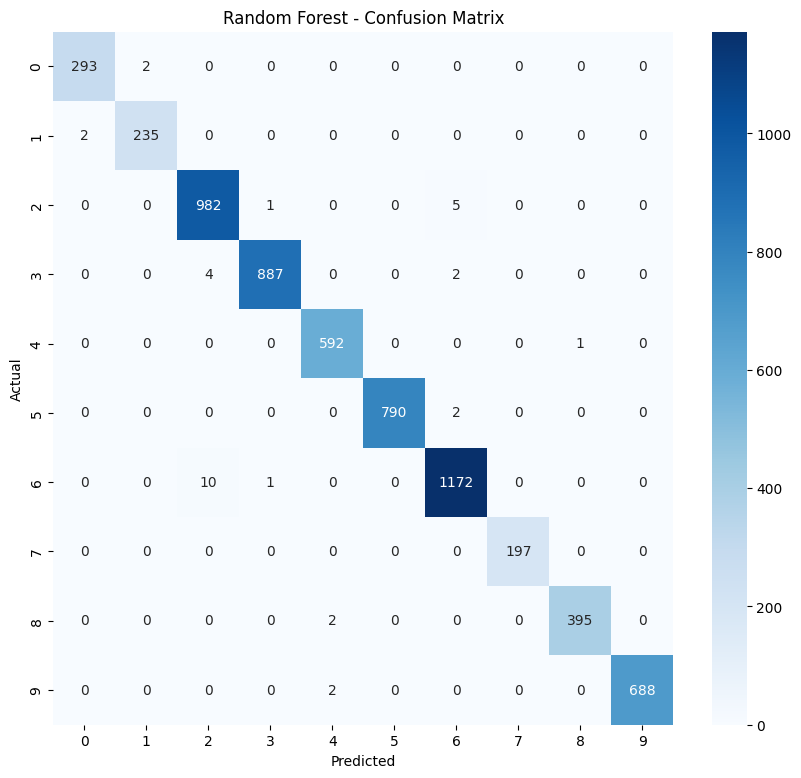

In [17]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score


y_pred1 = RF.predict(X_train)
y_pred2 = RF.predict(X_test)
train_acc = accuracy_score(y_train, y_pred1)
test_acc = accuracy_score(y_test, y_pred2)

print("Train accuracy after prediction :", train_acc)
print("Test accuracy after prediction:", test_acc)

print("Weighted F1:", f1_score(y_test, y_pred2, average="weighted"))
print("Macro F1:", f1_score(y_test, y_pred2, average="macro"))
print(classification_report(y_test, y_pred2))

# Confusion metrics

cm = confusion_matrix(y_test, y_pred2)

plt.figure(figsize = (10, 9))
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')


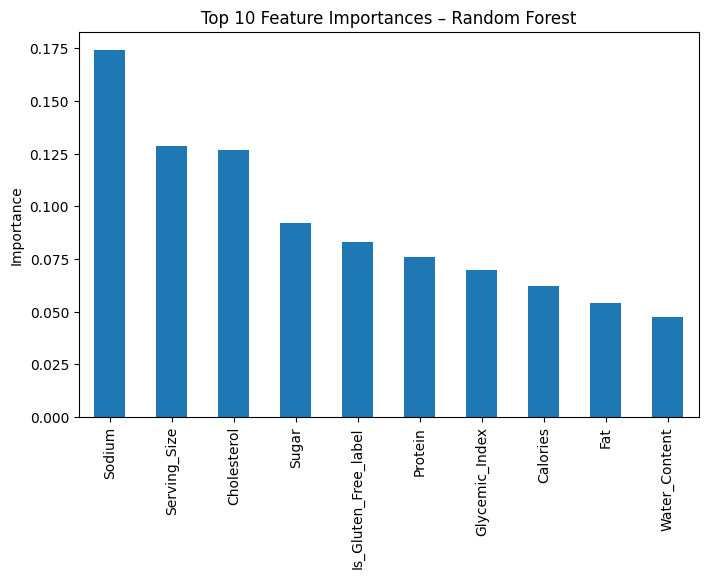

In [18]:
import pandas as pd

importances = pd.Series(
    RF.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances – Random Forest")
plt.ylabel("Importance")
plt.show()

In [14]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [5, 10, 15, 20, None]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

Best Parameters: {'max_depth': 15, 'n_estimators': 500}
Best CV Accuracy: 0.9944932162809257


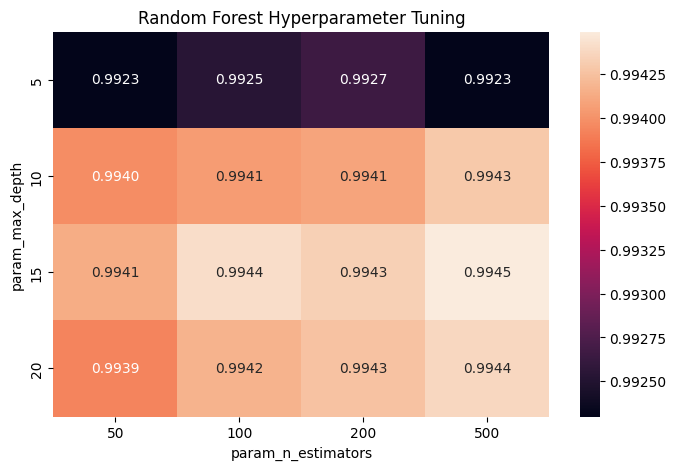

In [15]:
results = pd.DataFrame(grid.cv_results_)

pivot = results.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators'
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt=".4f")
plt.title("Random Forest Hyperparameter Tuning")
plt.show()